# Notebook A — EDA + Feature Engineering + Model Training
**Training window :** Jan 1 – Apr 30 2026
**Validation on  :** May 2026 (held-out test set)

Run all cells top to bottom. Expected total time: **20–30 min**.
Close Chrome and heavy apps before running Cell A6 onwards.

Outputs saved:
- `processed/retailer_day_features.parquet`
- `processed/label_encoders.pkl`
- `processed/retailer_profiles.parquet`
- `models/xgboost_order_model.pkl`

---
## ⚙️ A0 — Configuration (UPDATE YOUR PATH HERE)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, gc, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.metrics        import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
import xgboost as xgb

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

# ── UPDATE THIS ONE LINE ──────────────────────────────────────────────────────
BASE = r'C:\Users\Rishit\Desktop\O2R-Order-prediction'
# ─────────────────────────────────────────────────────────────────────────────

RAW_PATH      = os.path.join(BASE, 'data',      "Jan - May '26 Data.csv")
PARQUET_PATH  = os.path.join(BASE, 'processed', 'retailer_day_features.parquet')
ENCODER_PATH  = os.path.join(BASE, 'processed', 'label_encoders.pkl')
PROFILE_PATH  = os.path.join(BASE, 'processed', 'retailer_profiles.parquet')
MODEL_PATH    = os.path.join(BASE, 'models',    'xgboost_order_model.pkl')

os.makedirs(os.path.join(BASE, 'processed'), exist_ok=True)
os.makedirs(os.path.join(BASE, 'models'),    exist_ok=True)
os.makedirs(os.path.join(BASE, 'outputs'),   exist_ok=True)

# Training uses Jan-Apr; May is held out for evaluation
TRAIN_END  = '2026-04-30'
TEST_START = '2026-05-01'

print('Setup complete.')
print(f'   Base folder : {BASE}')
print(f'   Raw data    : {RAW_PATH}')
print(f'   Train period: Jan 1 → Apr 30 2026')
print(f'   Test period : May 1 → May 31 2026')

Setup complete.
   Base folder : C:\Users\Rishit\Desktop\O2R-Order-prediction
   Raw data    : C:\Users\Rishit\Desktop\O2R-Order-prediction\data\Jan - May '26 Data.csv
   Train period: Jan 1 → Apr 30 2026
   Test period : May 1 → May 31 2026


---
## 📊 A1 — Load Raw Data & Basic EDA

In [2]:
print('Loading raw CSV...')
df = pd.read_csv(RAW_PATH)
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)

print(f'\n=== RAW DATA OVERVIEW ===')
print(f'Total rows          : {len(df):,}')
print(f'Columns             : {df.shape[1]}')
print(f'Date range          : {df["createdAt"].min().date()} → {df["createdAt"].max().date()}')
print(f'Unique orders       : {df["orderNumber"].nunique():,}')
print(f'Unique retailers    : {df["customerId"].nunique():,}')

print(f'\n=== ORDER STATUS ===')
print(df['orderStatus'].value_counts().to_string())

print(f'\n=== ORDER SOURCE ===')
print(df['orderSource'].value_counts().to_string())

print(f'\n=== SHOP TYPE ===')
print(df['shopType'].value_counts().to_string())

# Null check on key columns
key_cols = ['createdAt','customerId','orderNumber','orderStatus','orderSource',
            'shopType','retailerType','hubName']
null_s = df[key_cols].isnull().sum()
print(f'\n=== NULLS IN KEY COLUMNS ===')
print(null_s[null_s > 0] if null_s.sum() > 0 else 'None. All clean.')

Loading raw CSV...



=== RAW DATA OVERVIEW ===
Total rows          : 609,723
Columns             : 30
Date range          : 2026-01-01 → 2026-05-31
Unique orders       : 200,201
Unique retailers    : 9,766

=== ORDER STATUS ===
orderStatus
Delivered             391923
PartiallyDelivered    151207
CANCELLED              66286
Created                  288
BatchAssigned             14
Dispatched                 5

=== ORDER SOURCE ===
orderSource
App              341161
CALLING_AGENT    268550
SUPER_ADMIN          12

=== SHOP TYPE ===
shopType
Paan B        207785
General A     134777
General B      94164
General C      90649
Paan A         49995
Paan C         25628
Wholesaler      2668
Chemist B       1438
Chemist A       1436
Chemist C       1183



=== NULLS IN KEY COLUMNS ===
retailerType    2546
dtype: int64


Confirmed unique orders : 177,340
Active retailers        : 8,640
Cancellation rate       : 33.1%


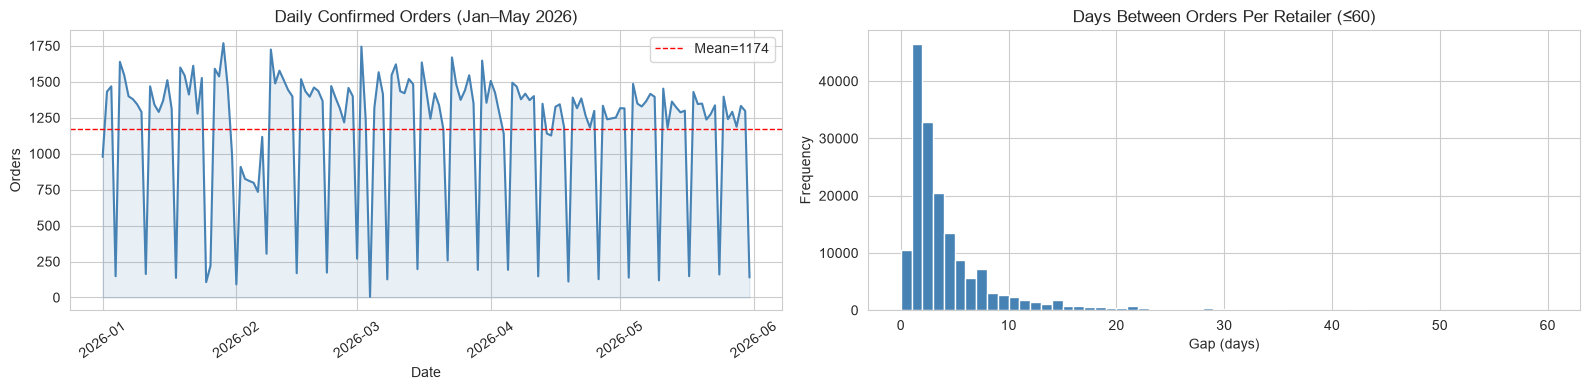


=== INTER-ORDER GAP STATS ===
count    168700.000000
mean          4.583942
std           7.629959
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         147.000000

Gap ≤ 1 day  : 56,998  (32.1%)
Gap 2-3 days : 53,361
Gap 4-7 days : 34,937
Gap > 7 days : 23,404


In [3]:
# Filter confirmed orders only
confirmed = df[df['orderStatus'].isin(['Delivered', 'PartiallyDelivered'])]
orders = confirmed.drop_duplicates(subset='orderNumber')[[
    'orderNumber','customerId','createdAt',
    'hubName','shopType','retailerType','orderSource'
]].copy()

orders['order_hour'] = orders['createdAt'].dt.hour

print(f'Confirmed unique orders : {len(orders):,}')
print(f'Active retailers        : {orders["customerId"].nunique():,}')
print(f'Cancellation rate       : {(df["orderStatus"]=="CANCELLED").sum()/df["orderNumber"].nunique()*100:.1f}%')

# Daily order volume plot
daily = orders.groupby(orders['createdAt'].dt.date)['orderNumber'].count().reset_index()
daily.columns = ['date','orders']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Plot 1: daily orders
axes[0].plot(daily['date'], daily['orders'], color='steelblue', lw=1.5)
axes[0].fill_between(daily['date'], daily['orders'], alpha=0.12, color='steelblue')
axes[0].axhline(daily['orders'].mean(), color='red', lw=1, linestyle='--',
                label=f'Mean={daily["orders"].mean():.0f}')
axes[0].set_title('Daily Confirmed Orders (Jan–May 2026)')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=35); axes[0].legend()

# Plot 2: inter-order gap
o = orders.sort_values(['customerId','createdAt'])
o['gap'] = o.groupby('customerId')['createdAt'].diff().dt.days
gaps = o[o['gap'].notna() & (o['gap'] <= 60)]
axes[1].hist(gaps['gap'], bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Days Between Orders Per Retailer (≤60)')
axes[1].set_xlabel('Gap (days)'); axes[1].set_ylabel('Frequency')

plt.tight_layout(); plt.show()

print(f'\n=== INTER-ORDER GAP STATS ===')
print(o['gap'].describe().to_string())
print(f'\nGap ≤ 1 day  : {(o["gap"]<=1).sum():,}  ({(o["gap"]<=1).mean()*100:.1f}%)')
print(f'Gap 2-3 days : {((o["gap"]>=2)&(o["gap"]<=3)).sum():,}')
print(f'Gap 4-7 days : {((o["gap"]>=4)&(o["gap"]<=7)).sum():,}')
print(f'Gap > 7 days : {(o["gap"]>7).sum():,}')

In [4]:
# Retailer frequency & class imbalance preview
freq = orders.groupby('customerId')['orderNumber'].count()
print('=== ORDERS PER RETAILER ===')
print(freq.describe().to_string())
print(f'\nOnly 1 order (cold start) : {(freq==1).sum()}')
print(f'2–5 orders                : {((freq>=2)&(freq<=5)).sum()}')
print(f'6+ orders (ML-ready)      : {(freq>=6).sum()}')

# Class imbalance numbers
n_retailers = orders['customerId'].nunique()
n_days      = (df['createdAt'].max() - df['createdAt'].min()).days + 1
grid_size   = n_retailers * n_days
positives   = len(orders)
print(f'\n=== CLASS IMBALANCE PREVIEW ===')
print(f'Grid size  : {grid_size:,}  (retailers × days)')
print(f'Positive   : {positives:,}  ({positives/grid_size*100:.1f}%)')
print(f'Negative   : {grid_size-positives:,}  ({(grid_size-positives)/grid_size*100:.1f}%)')
print(f'Ratio neg:pos → {(grid_size-positives)//positives}:1  (handled via scale_pos_weight in XGBoost)')

del df  # free memory before feature engineering
gc.collect()
print('\n✅ EDA complete. Raw df freed from memory.')

=== ORDERS PER RETAILER ===
count    8640.000000
mean       20.525463
std        24.292309
min         1.000000
25%         3.000000
50%        11.000000
75%        29.000000
max       190.000000

Only 1 order (cold start) : 1175
2–5 orders                : 1904
6+ orders (ML-ready)      : 5561

=== CLASS IMBALANCE PREVIEW ===
Grid size  : 1,304,640  (retailers × days)
Positive   : 177,340  (13.6%)
Negative   : 1,127,300  (86.4%)
Ratio neg:pos → 6:1  (handled via scale_pos_weight in XGBoost)

✅ EDA complete. Raw df freed from memory.


---
## 🔧 A2 — Build Retailer Static Profile

In [5]:
print('Building retailer profiles...')

retailer_profile = orders.groupby('customerId').agg(
    hubName      = ('hubName',      lambda x: x.mode()[0]),
    shopType     = ('shopType',     lambda x: x.mode()[0]),
    retailerType = ('retailerType', lambda x: x.mode()[0] if x.notna().any() else 'Unknown'),
    app_orders   = ('orderSource',  lambda x: (x == 'App').sum()),
    total_orders = ('orderNumber',  'count'),
    first_order  = ('createdAt',    'min'),
    last_order   = ('createdAt',    'max'),
    favorite_order_hour = ('order_hour', lambda x: x.mode()[0] if not x.empty else 0),
).reset_index()

retailer_profile['app_order_ratio'] = (
    retailer_profile['app_orders'] / retailer_profile['total_orders']
).round(4)
retailer_profile['retailerType'] = retailer_profile['retailerType'].fillna('Unknown')

def map_hour(h):
    if 5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 24: return 'Evening'
    else: return 'Late Night'
retailer_profile['best_time_to_call'] = retailer_profile['favorite_order_hour'].apply(map_hour)

retailer_profile.to_parquet(PROFILE_PATH, index=False)
print(f'✅ Profile built for {len(retailer_profile):,} retailers → saved to {PROFILE_PATH}')
retailer_profile.head(3)

Building retailer profiles...


✅ Profile built for 8,640 retailers → saved to C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\retailer_profiles.parquet


,customerId,hubName,shopType,retailerType,app_orders,total_orders,first_order,last_order,favorite_order_hour,app_order_ratio,best_time_to_call
0,USR-100,Crossline Events (Noida),Paan A,HVLF,12,13,2026-01-02,2026-05-27,0,0.9231,Late Night
1,USR-1000,Instant Foods(Noida),General B,HVLF,0,3,2026-01-10,2026-05-16,0,0.0000,Late Night
2,USR-100021,Instant Foods (SED),General A,HVLF,2,4,2026-02-14,2026-03-30,0,0.5000,Late Night


---
## 🔧 A3 — Build Retailer-Day Grid & Label (Target Variable)
**⚠️ This cell takes ~3–5 min. Do not interrupt.**

In [6]:
all_retailers = orders['customerId'].unique()
# Grid spans full Jan-May so rolling features are available for May rows too
all_dates = pd.date_range(
    start=orders['createdAt'].min(),
    end=orders['createdAt'].max(),
    freq='D'
)

print(f'Retailers  : {len(all_retailers):,}')
print(f'Days       : {len(all_dates)}  ({all_dates[0].date()} → {all_dates[-1].date()})')
print(f'Grid size  : {len(all_retailers)*len(all_dates):,} rows')
print('Building grid...')

idx  = pd.MultiIndex.from_product([all_retailers, all_dates],
                                   names=['customerId','date'])
grid = pd.DataFrame(index=idx).reset_index()

# Label rows
order_flags = orders[['customerId','createdAt']].copy()
order_flags = order_flags.rename(columns={'createdAt':'date'})
order_flags['ordered_today'] = 1
order_flags = order_flags.drop_duplicates(subset=['customerId','date'])

grid = grid.merge(order_flags, on=['customerId','date'], how='left')
grid['ordered_today'] = grid['ordered_today'].fillna(0).astype(int)

print(f'\nGrid built: {len(grid):,} rows')
print(f'Positive (ordered=1) : {grid["ordered_today"].sum():,}  ({grid["ordered_today"].mean()*100:.1f}%)')
print(f'Negative (ordered=0) : {(grid["ordered_today"]==0).sum():,}')

Retailers  : 8,640
Days       : 151  (2026-01-01 → 2026-05-31)
Grid size  : 1,304,640 rows
Building grid...



Grid built: 1,304,640 rows
Positive (ordered=1) : 166,864  (12.8%)
Negative (ordered=0) : 1,137,776


---
## 🔧 A4 — Feature Engineering
**⚠️ Heaviest step. Takes 10–15 min. Close other apps now.**
All features use only data from BEFORE each row's date (no leakage).

In [7]:
print('Sorting grid...')
grid = grid.sort_values(['customerId','date']).reset_index(drop=True)
grid['_ord'] = grid['ordered_today']

print('Computing rolling order counts (shift=1 prevents leakage)...')
grp = grid.groupby('customerId')['_ord']

grid['orders_last_3_days']  = grp.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).sum())
grid['orders_last_7_days']  = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).sum())
grid['orders_last_14_days'] = grp.transform(lambda x: x.shift(1).rolling(14, min_periods=1).sum())
grid['orders_last_30_days'] = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).sum())
grid['total_orders_so_far'] = grp.transform(lambda x: x.shift(1).expanding().sum())
grid['momentum_7_30'] = grid['orders_last_7_days'] / (grid['orders_last_30_days'] + 1)
grid['momentum_14_30'] = grid['orders_last_14_days'] / (grid['orders_last_30_days'] + 1)

print('Rolling counts done.')
gc.collect()

Sorting grid...
Computing rolling order counts (shift=1 prevents leakage)...


Rolling counts done.


0

In [8]:
print('Computing days_since_last_order...')

grid['_order_date']     = grid['date'].where(grid['_ord'] == 1)
grid['last_order_date'] = grid.groupby('customerId')['_order_date'].transform(
    lambda x: x.shift(1).ffill()
)
grid['days_since_last_order'] = (grid['date'] - grid['last_order_date']).dt.days
grid['days_since_last_order'] = grid['days_since_last_order'].fillna(999)

print('Computing inter-order gap stats...')
orders_s = orders.sort_values(['customerId','createdAt'])
orders_s['gap'] = orders_s.groupby('customerId')['createdAt'].diff().dt.days

gap_stats = orders_s.groupby('customerId')['gap'].agg(
    avg_gap_between_orders = 'mean',
    std_gap_between_orders = 'std',
    median_gap             = 'median'
).reset_index()
gap_stats = gap_stats.fillna({'avg_gap_between_orders':30,
                               'std_gap_between_orders':0,
                               'median_gap':30})

grid = grid.merge(gap_stats, on='customerId', how='left')

print('Computing overdue & regularity features...')
grid['expected_next_order'] = (
    grid['last_order_date'] +
    pd.to_timedelta(grid['avg_gap_between_orders'], unit='D')
)
grid['days_overdue']     = (grid['date'] - grid['expected_next_order']).dt.days.fillna(0)
grid['is_overdue']       = (grid['days_overdue'] > 0).astype(int)
grid['order_regularity'] = 1 / (grid['std_gap_between_orders'] + 1)
grid['overdue_ratio']    = (
    grid['days_since_last_order'] / (grid['avg_gap_between_orders'] + 1)
).clip(upper=10).round(3)

print('Adding temporal features...')
grid['day_of_week']    = grid['date'].dt.dayofweek
grid['day_of_month']   = grid['date'].dt.day
grid['week_of_month']  = (grid['date'].dt.day - 1) // 7 + 1
grid['month']          = grid['date'].dt.month
grid['is_weekend']     = (grid['date'].dt.dayofweek >= 5).astype(int)
grid['is_month_start'] = (grid['date'].dt.day <= 3).astype(int)
grid['is_month_end']   = (grid['date'].dt.day >= 28).astype(int)

print('Merging retailer profile...')
grid = grid.merge(
    retailer_profile[['customerId','hubName','shopType','retailerType',
                       'app_order_ratio','first_order','favorite_order_hour']],
    on='customerId', how='left'
)
grid['retailerType'] = grid['retailerType'].fillna('Unknown')
grid['tenure_days'] = (grid['date'] - grid['first_order']).dt.days
grid['tenure_days'] = grid['tenure_days'].clip(lower=0).fillna(0)

print('✅ All features computed.')
gc.collect()

Computing days_since_last_order...


Computing inter-order gap stats...


Computing overdue & regularity features...


Adding temporal features...


Merging retailer profile...


✅ All features computed.


99

In [9]:
print('Encoding categoricals & saving encoders...')
cat_cols       = ['hubName','shopType','retailerType']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    grid[col + '_enc'] = le.fit_transform(grid[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {grid[col].nunique()} categories encoded')

with open(ENCODER_PATH, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f'  Encoders saved → {ENCODER_PATH}')

# Drop temp helper columns
drop_cols = ['_ord','_order_date','last_order_date','expected_next_order']
grid = grid.drop(columns=[c for c in drop_cols if c in grid.columns])

FEATURE_COLS = [
    'days_since_last_order',
    'avg_gap_between_orders',
    'std_gap_between_orders',
    'median_gap',
    'orders_last_3_days',
    'orders_last_7_days',
    'orders_last_14_days',
    'orders_last_30_days',
        'momentum_7_30',
        'momentum_14_30',
    'total_orders_so_far',
    'days_overdue',
    'is_overdue',
    'order_regularity',
    'overdue_ratio',
    'app_order_ratio',
    'tenure_days',
    'favorite_order_hour',
    'day_of_week',
    'day_of_month',
    'week_of_month',
    'month',
    'is_weekend',
    'is_month_start',
    'is_month_end',
    'hubName_enc',
    'shopType_enc',
    'retailerType_enc',
]
TARGET_COL = 'ordered_today'

# Fill any remaining nulls
null_check = grid[FEATURE_COLS].isnull().sum()
if null_check.sum() > 0:
    print(f'  Filling {null_check.sum()} remaining nulls with 0')
    grid[FEATURE_COLS] = grid[FEATURE_COLS].fillna(0)
else:
    print('  No nulls in feature columns.')

print(f'\nFinal grid: {grid.shape[0]:,} rows × {len(FEATURE_COLS)} features')

print('Saving to parquet...')
grid.to_parquet(PARQUET_PATH, index=False)
print(f'✅ Saved → {PARQUET_PATH}  ({os.path.getsize(PARQUET_PATH)/(1024**2):.1f} MB)')

Encoding categoricals & saving encoders...


  hubName: 11 categories encoded


  shopType: 10 categories encoded


  retailerType: 4 categories encoded
  Encoders saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\label_encoders.pkl


  Filling 60480 remaining nulls with 0



Final grid: 1,304,640 rows × 28 features
Saving to parquet...


✅ Saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\retailer_day_features.parquet  (5.6 MB)


---
## 🤖 A5 — Model Training & Evaluation
Train on Jan–Apr, evaluate on May (true held-out test).

In [10]:
# Reload from parquet (clean state)
print('Loading feature data from parquet...')
grid = pd.read_parquet(PARQUET_PATH)
grid['date'] = pd.to_datetime(grid['date'])
print(f'Loaded: {grid.shape}')

# Time-based split
train = grid[grid['date'] <= TRAIN_END]
test  = grid[grid['date'] >= TEST_START]

print(f'\nTrain (Jan–Apr): {len(train):,} rows | positive: {train[TARGET_COL].mean()*100:.1f}%')
print(f'Test  (May)    : {len(test):,}  rows | positive: {test[TARGET_COL].mean()*100:.1f}%')

X_train = np.nan_to_num(train[FEATURE_COLS].values, nan=0.0)
y_train = train[TARGET_COL].values
X_test  = np.nan_to_num(test[FEATURE_COLS].values,  nan=0.0)
y_test  = test[TARGET_COL].values

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'\nscale_pos_weight (neg/pos ratio): {scale_pos_weight:.2f}')

Loading feature data from parquet...


Loaded: (1304640, 35)

Train (Jan–Apr): 1,036,800 rows | positive: 12.9%
Test  (May)    : 267,840  rows | positive: 12.5%



scale_pos_weight (neg/pos ratio): 6.77


In [11]:
# ── Baseline: Logistic Regression ────────────────────────────────────────────
print('Training Logistic Regression baseline...')
scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_tr_s, y_train)
lr_preds = lr.predict(X_test_s)

print('\n=== LOGISTIC REGRESSION — May 2026 Test ===')
print(classification_report(y_test, lr_preds, target_names=['No Order','Ordered']))

Training Logistic Regression baseline...



=== LOGISTIC REGRESSION — May 2026 Test ===
              precision    recall  f1-score   support

    No Order       0.96      0.79      0.86    234474
     Ordered       0.33      0.74      0.46     33366

    accuracy                           0.78    267840
   macro avg       0.64      0.77      0.66    267840
weighted avg       0.88      0.78      0.81    267840



In [12]:
# ── Main Model: XGBoost ───────────────────────────────────────────────────────
print('Training XGBoost (5–10 min)...')

xgb_model = xgb.XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist'
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

print('\n=== XGBOOST — May 2026 Test ===')
print(classification_report(y_test, xgb_preds, target_names=['No Order','Ordered']))

Training XGBoost (5–10 min)...


[0]	validation_0-logloss:0.67408


[50]	validation_0-logloss:0.44603


[100]	validation_0-logloss:0.42159


[150]	validation_0-logloss:0.40586


...

[250]	validation_0-logloss:0.38629


[300]	validation_0-logloss:0.37489


[350]	validation_0-logloss:0.36529


[399]	validation_0-logloss:0.35988



=== XGBOOST — May 2026 Test ===
              precision    recall  f1-score   support

    No Order       0.96      0.84      0.90    234474
     Ordered       0.40      0.76      0.53     33366

    accuracy                           0.83    267840
   macro avg       0.68      0.80      0.71    267840
weighted avg       0.89      0.83      0.85    267840



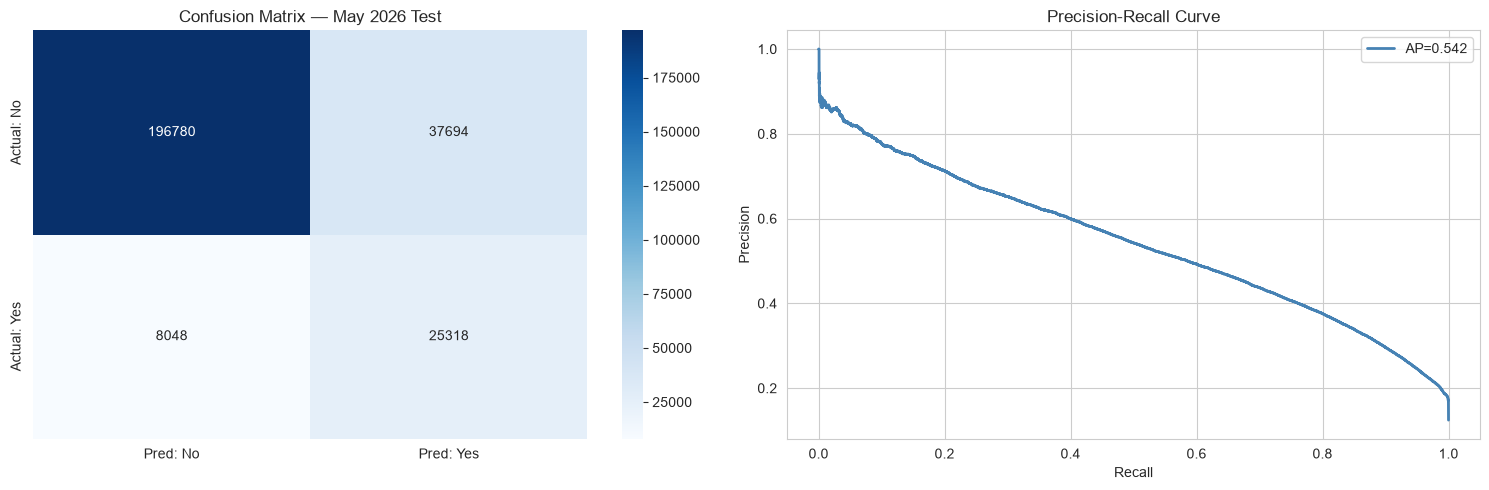

True Positives  (orders correctly caught) : 25,318
False Positives (wasted calls)            : 37,694
False Negatives (missed orders)           : 8,048
True Negatives  (correctly skipped)       : 196,780


In [13]:
# ── Evaluation Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No','Pred: Yes'],
            yticklabels=['Actual: No','Actual: Yes'])
axes[0].set_title('Confusion Matrix — May 2026 Test', fontsize=12)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, xgb_probs)
ap = average_precision_score(y_test, xgb_probs)
axes[1].plot(recall, precision, color='steelblue', lw=2, label=f'AP={ap:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=12)
axes[1].legend()

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (orders correctly caught) : {tp:,}')
print(f'False Positives (wasted calls)            : {fp:,}')
print(f'False Negatives (missed orders)           : {fn:,}')
print(f'True Negatives  (correctly skipped)       : {tn:,}')

In [14]:
# ── Threshold Analysis Table ─────────────────────────────────────────────────
total_retailers_test = test['customerId'].nunique()
total_actual_orders  = int(y_test.sum())

print(f'May 2026 test set: {total_retailers_test:,} retailers | {total_actual_orders:,} actual orders')
print()

rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p         = (xgb_probs >= t).astype(int)
    calls     = int(p.sum())
    captured  = int(((p==1) & (y_test==1)).sum())
    prec      = precision_score(y_test, p, zero_division=0)
    rec       = recall_score(y_test,    p, zero_division=0)
    f1        = f1_score(y_test,        p, zero_division=0)
    reduction = (1 - calls/total_retailers_test)*100
    rows.append({
        'Threshold'      : f'{int(t*100)}%',
        'Calls Made'     : f'{calls:,}',
        'Call Reduction' : f'{reduction:.0f}%',
        'Orders Captured': f'{captured:,}',
        'Orders Missed'  : f'{total_actual_orders-captured:,}',
        'Precision'      : f'{prec*100:.1f}%',
        'Recall'         : f'{rec*100:.1f}%',
        'F1'             : f'{f1:.3f}'
    })

thresh_df = pd.DataFrame(rows)
print('=== THRESHOLD ANALYSIS (show this to your sir) ===')
print(thresh_df.to_string(index=False))

May 2026 test set: 8,640 retailers | 33,366 actual orders



=== THRESHOLD ANALYSIS (show this to your sir) ===
Threshold Calls Made Call Reduction Orders Captured Orders Missed Precision Recall    F1
      20%    129,890         -1403%          31,744         1,622     24.4%  95.1% 0.389
      30%    103,698         -1100%          30,195         3,171     29.1%  90.5% 0.441
      40%     81,843          -847%          28,139         5,227     34.4%  84.3% 0.488
      50%     63,012          -629%          25,318         8,048     40.2%  75.9% 0.525
      60%     47,552          -450%          21,963        11,403     46.2%  65.8% 0.543
      70%     33,604          -289%          17,690        15,676     52.6%  53.0% 0.528
      80%     20,087          -132%          12,365        21,001     61.6%  37.1% 0.463


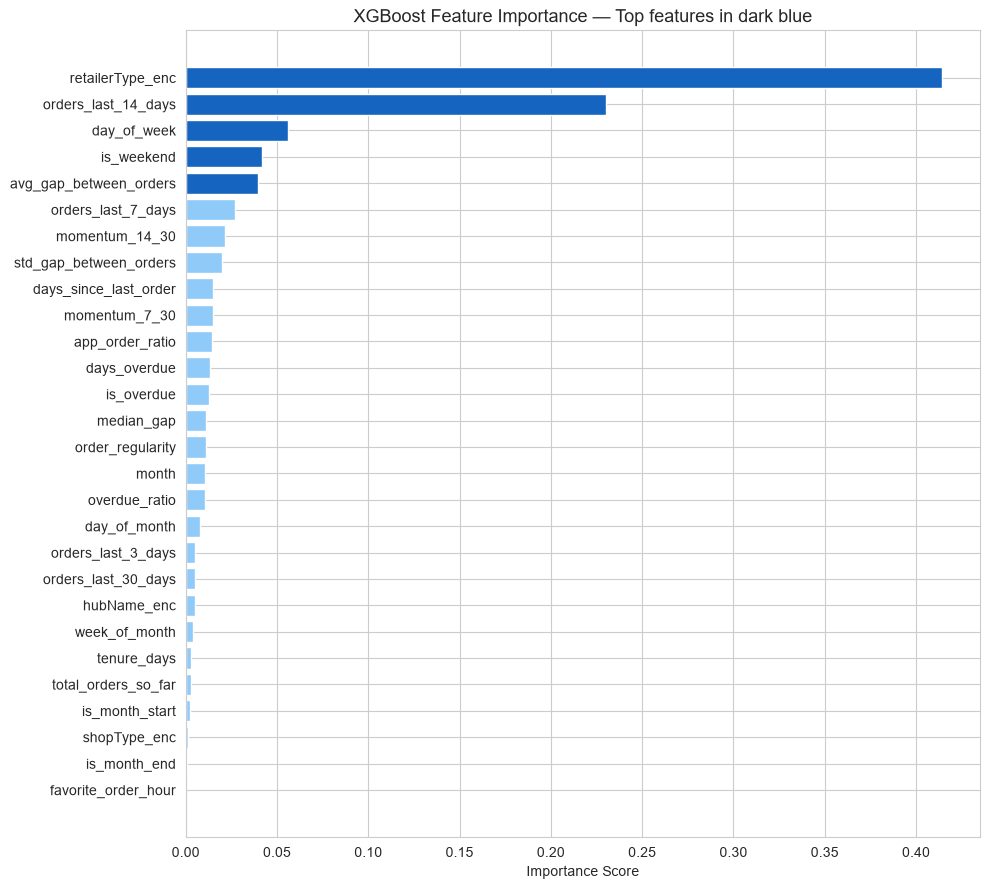

Top 5 features:
               Feature  Importance
avg_gap_between_orders    0.039563
            is_weekend    0.041954
           day_of_week    0.055933
   orders_last_14_days    0.229959
      retailerType_enc    0.414306


In [15]:
# ── Feature Importance ────────────────────────────────────────────────────────
feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#1565C0' if i >= len(feat_df)-5 else '#90CAF9'
          for i in range(len(feat_df))]
plt.figure(figsize=(10, 9))
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
plt.title('XGBoost Feature Importance — Top features in dark blue', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('Top 5 features:')
print(feat_df.tail(5)[['Feature','Importance']].to_string(index=False))

In [16]:
# ── Save Model ────────────────────────────────────────────────────────────────
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model'        : xgb_model,
        'feature_cols' : FEATURE_COLS,
        'threshold'    : 0.4,
        'trained_on'   : 'Jan–Apr 2026',
        'predicts_for' : 'May 2026'
    }, f)

print(f'✅ Model saved → {MODEL_PATH}')
print()
print('=== NOTEBOOK A COMPLETE ===')
print('Next → Run Notebook B (Predictions + Output)')

✅ Model saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_order_model.pkl

=== NOTEBOOK A COMPLETE ===
Next → Run Notebook B (Predictions + Output)


---
## 🚀 A6 — CatBoost Benchmark
Train CatBoost and compare against XGBoost.

In [17]:
!pip install -q catboost
from catboost import CatBoostClassifier

print('Training CatBoost...')
cat_model = CatBoostClassifier(
    iterations=400,
    depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='Logloss',
    random_seed=42,
    verbose=50
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

cat_probs = cat_model.predict_proba(X_test)[:, 1]
cat_preds = cat_model.predict(X_test)

print('\n=== CATBOOST — May 2026 Test ===')
print(classification_report(y_test, cat_preds, target_names=['No Order','Ordered']))

xgb_f1 = f1_score(y_test, xgb_preds)
cat_f1 = f1_score(y_test, cat_preds)

print(f'\nXGBoost F1:  {xgb_f1:.4f}')
print(f'CatBoost F1: {cat_f1:.4f}')

if cat_f1 > xgb_f1:
    print('\n🏆 CatBoost outperforms XGBoost! Saving CatBoost model...')
    import pickle
    CAT_MODEL_PATH = os.path.join(BASE, 'models', 'catboost_order_model.pkl')
    with open(CAT_MODEL_PATH, 'wb') as f:
        pickle.dump(cat_model, f)
    print(f'Saved to {CAT_MODEL_PATH}')
else:
    print('\n🏆 XGBoost remains the best model. No changes to saved model.')


Training CatBoost...


0:	learn: 0.6663361	test: 0.6652060	best: 0.6652060 (0)	total: 255ms	remaining: 1m 41s


50:	learn: 0.4629792	test: 0.4487821	best: 0.4487821 (50)	total: 5.26s	remaining: 36s


100:	learn: 0.4499765	test: 0.4336455	best: 0.4334050 (94)	total: 10s	remaining: 29.6s


150:	learn: 0.4423632	test: 0.4348064	best: 0.4317813 (110)	total: 14.8s	remaining: 24.5s


...

250:	learn: 0.4337113	test: 0.4395518	best: 0.4317813 (110)	total: 24.6s	remaining: 14.6s


300:	learn: 0.4308985	test: 0.4392512	best: 0.4317813 (110)	total: 29.7s	remaining: 9.76s


350:	learn: 0.4286388	test: 0.4377964	best: 0.4317813 (110)	total: 34.5s	remaining: 4.82s


399:	learn: 0.4268789	test: 0.4367296	best: 0.4317813 (110)	total: 39.6s	remaining: 0us

bestTest = 0.4317812967
bestIteration = 110

Shrink model to first 111 iterations.

=== CATBOOST — May 2026 Test ===


              precision    recall  f1-score   support

    No Order       0.97      0.79      0.87    234474
     Ordered       0.36      0.81      0.49     33366

    accuracy                           0.79    267840
   macro avg       0.66      0.80      0.68    267840
weighted avg       0.89      0.79      0.82    267840


XGBoost F1:  0.5254
CatBoost F1: 0.4943

🏆 XGBoost remains the best model. No changes to saved model.
